In [5]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.fft import fftshift,fftfreq
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True

In [6]:
N = 192


In [7]:
datapath = lambda f_corr,N_b,ti,tf: f"/mnt/pfs/rajarshi.chattopadhyay/codes/boussinesq/data/bsnq/f_{f_corr:.1f}_Nb_{N_b:.1f}/forced_True/N_{N}_Re_9903520314283066388448804864.0/e_omg_kh_kz_ti_{ti:.3f}_tf_{tf:.3f}.hdf5"

In [16]:
times_o = np.arange(0,31.4,0.1)
Ntimes = len(times_o)
freqs = 2*np.pi/(times_o[-1] - times_o[0])*fftfreq(Ntimes,1./Ntimes)
freqs_pos = np.abs(2*np.pi/(times_o[-1] - times_o[0])*fftfreq(Ntimes,1./Ntimes)[:Ntimes//2 + 1])
domega = freqs[1] - freqs[0]
Kz = Kh = np.arange(0,N//2+1)
shells = np.arange(-0.5,N//2+1)
shells[0] = 0.
omg,kh,kz = np.meshgrid(freqs,Kh,Kz,indexing = 'ij')
omg_shells = np.array(list(freqs_pos - 0.5*freqs_pos[1]) + [freqs_pos[-1] + 0.5*freqs_pos[1]])
freqs = fftshift(freqs)

In [9]:
def get_pos_omg(x):
    return np.histogramdd(np.concatenate((np.abs(omg).ravel()[:,None],kh.ravel()[:,None],kz.ravel()[:,None]),axis = 1),bins = [omg_shells,shells,shells],weights = x.ravel())[0]

In [10]:
omg_kh_kz = []
omg_pos_kh_kz = []
f_corrs = [1,5]
N_b = 20
for i,f_corr in enumerate(f_corrs):
    ti = 0.0
    tf = 31.4/f_corr
    with h5py.File(datapath(f_corr,N_b,ti,tf),'r') as f:
        omg_kh_kz.append(np.sum(f['e_u_omg_kh_kz'],axis = 1)  + f['e_b_omg_kh_kz'][:])
    omg_kh_kz[i] /= np.sum(omg_kh_kz[i])
    omg_pos_kh_kz.append(get_pos_omg(omg_kh_kz[i]))
        
omg_kh_kz = np.array(omg_kh_kz)

In [11]:
omg_disp = lambda f,kh,kz,Nb = N_b : ((N_b**2 * kh**2 + f*kz**2)/(kh**2 + kz**2))**0.5/f

In [13]:
norm = LogNorm(vmin = 1e-6,vmax = 1)

/tmp/ipykernel_295660/143301089.py:1: RuntimeWarning: invalid value encountered in divide
  omg_disp = lambda f,kh,kz,Nb = N_b : ((N_b**2 * kh**2 + f*kz**2)/(kh**2 + kz**2))**0.5/f


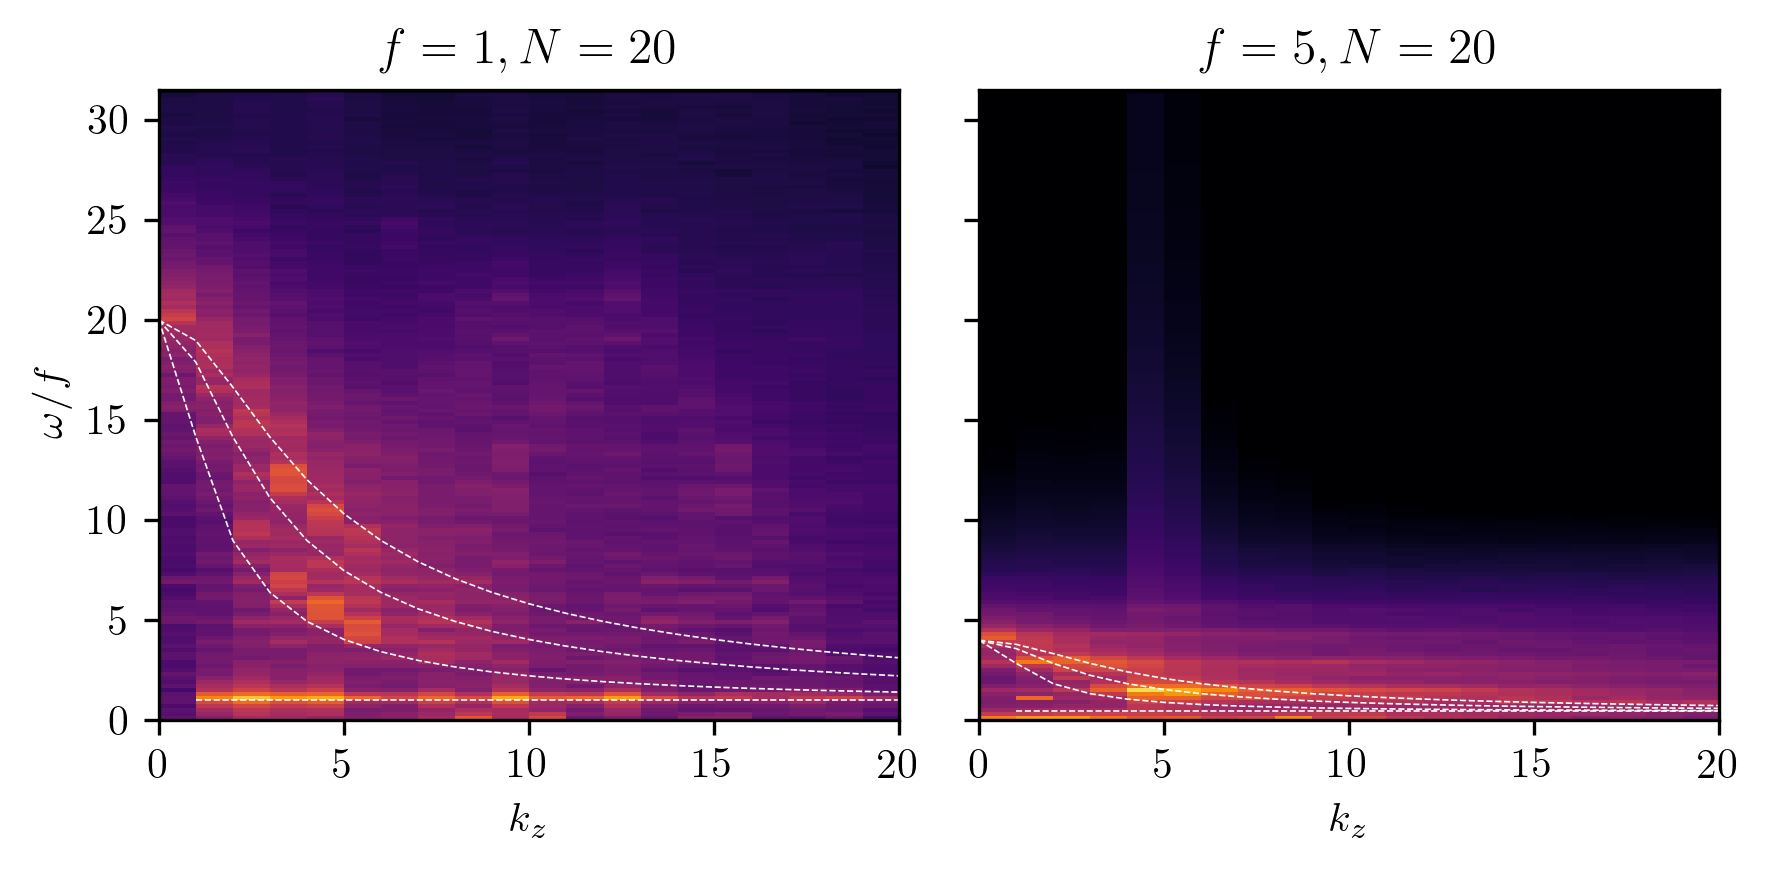

In [23]:
fig,ax = plt.subplots(1,2,figsize = (6,3),dpi = 300,sharey = True)
for i in range(2):
    ax[i].imshow(omg_pos_kh_kz[i].sum(axis = 1),extent = [0,N//2 + 1, freqs_pos[0],freqs_pos[-1]],origin = 'lower',aspect = 'auto',cmap = "inferno",norm = norm)
    ax[i].set_xlim(0,20)
    for kkh in range(4):
        ax[i].plot(Kz,omg_disp(f_corrs[i],kkh,Kz),color = 'white',ls = '--',lw = 0.4)
    # ax[i].set_ylim(0,None)
    ax[i].set_xlabel(r'$k_z$')
    ax[i].set_title(f"$f = {f_corrs[i]}, N = {N_b}$")
ax[0].set_ylabel(r'$\omega/f$')
fig.tight_layout()

/tmp/ipykernel_295660/143301089.py:1: RuntimeWarning: invalid value encountered in divide
  omg_disp = lambda f,kh,kz,Nb = N_b : ((N_b**2 * kh**2 + f*kz**2)/(kh**2 + kz**2))**0.5/f


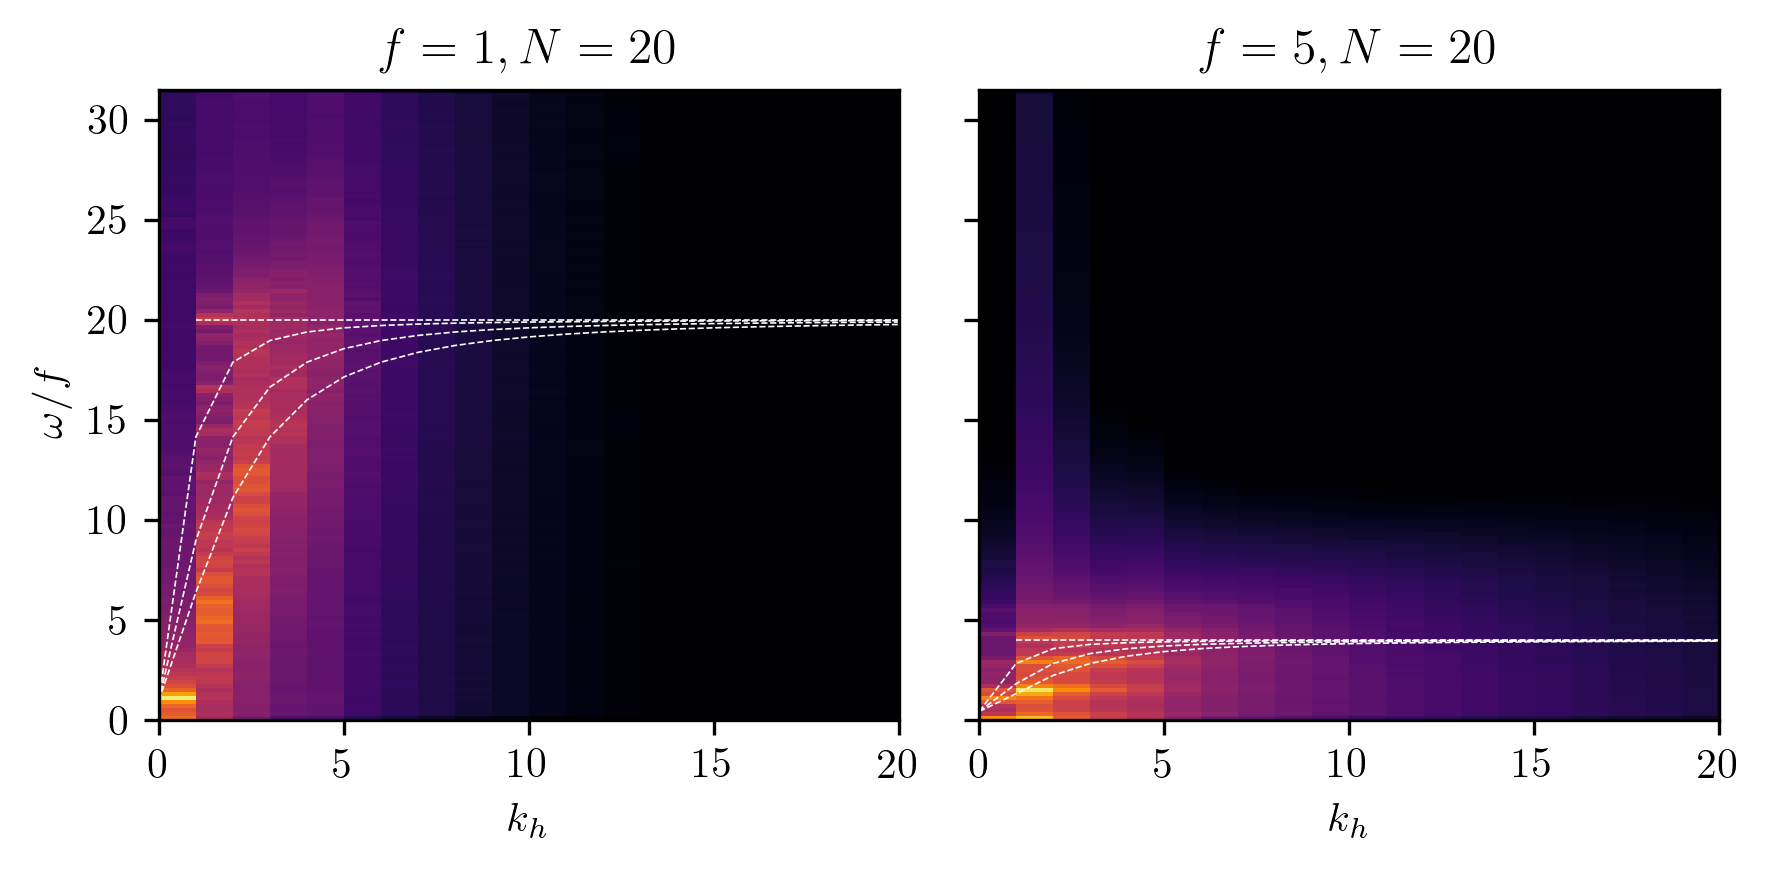

In [27]:
fig,ax = plt.subplots(1,2,figsize = (6,3),dpi = 300,sharey = True)
for i in range(2):
    ax[i].imshow(omg_pos_kh_kz[i].sum(axis = 2),extent = [0,N//2 + 1, freqs_pos[0],freqs_pos[-1]],origin = 'lower',aspect = 'auto',cmap = "inferno",norm = norm)
    ax[i].set_xlim(0,20)
    for kkz in range(4):
        ax[i].plot(Kh,omg_disp(f_corrs[i],Kh,kkz),color = 'white',ls = '--',lw = 0.4)
    # ax[i].set_ylim(0,None)
    ax[i].set_xlabel(r'$k_h$')
    ax[i].set_title(f"$f = {f_corrs[i]}, N = {N_b}$")
ax[0].set_ylabel(r'$\omega/f$')
fig.tight_layout()

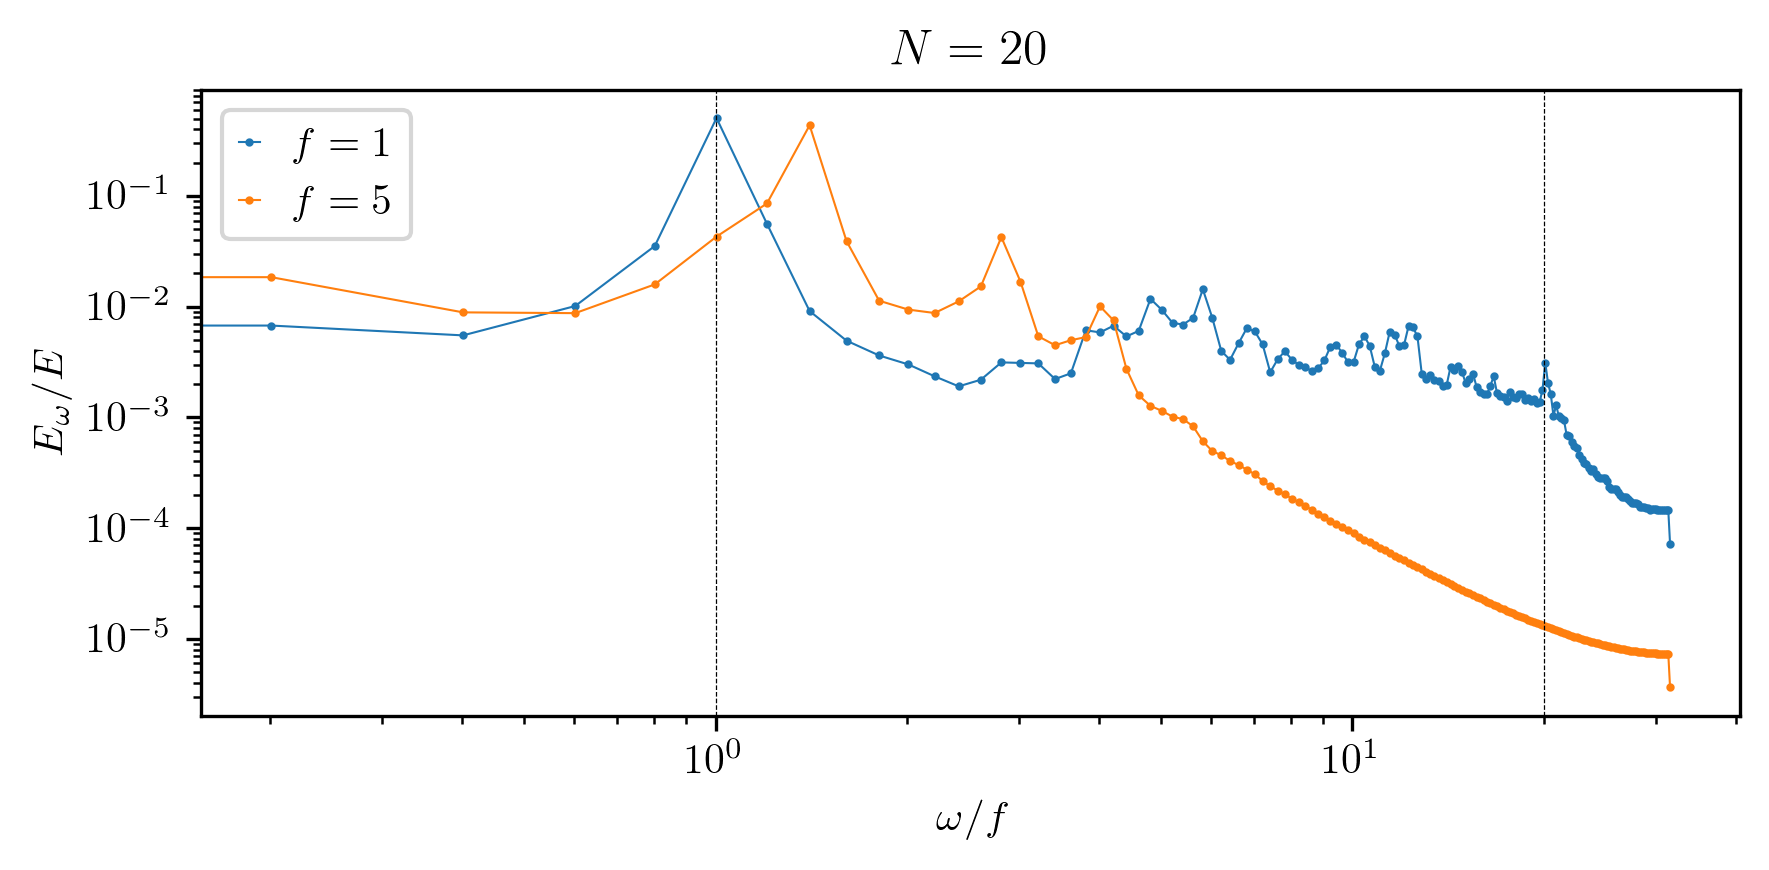

In [90]:
fig,ax = plt.subplots(1,1,figsize = (6,3),dpi = 300,sharey = True)

freqs
for i in range(2):
    ax.plot(freqs_pos,omg_pos_kh_kz[i].sum(axis = (1,2)),'.-',ms = 2,lw = 0.5,label = f"$f = {f_corrs[i]}$")

    # ax.set_xscale('symlog', base = 2,linthresh = freqs_pos[1],linscale=0.1)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(freqs_pos[1],None)
# ax.set_ylim(0,None)
ax.set_xlabel(r'$\omega/f$')
ax.set_title(f"$N = {N_b}$")
freqlines = [1,20]
for f in freqlines:
    ax.axvline(f,ls = '--',color = 'k',lw = 0.3)
ax.set_ylabel(r"$E_{{\omega}}/E$")
ax.legend(handlelength=0.5)
fig.tight_layout()
